<a href="https://colab.research.google.com/github/rayanecardozo/projects-computer-vision/blob/main/Exerc%C3%ADcio_03_RN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Introdução - Usando GPUs para treinar Redes Neurais

O longo tempo de treinamento de algumas redes neurais (como vocês viram no Laboratório 06) muitas vezes impedia o uso desse tipo de rede e

Porém, com o desenvolvimento das GPUs, foi possível paralelizar o treinamento nesses hardwares, o que acelerou (e muito) o desenvolvimento das inteligências artificiais.

Por sorte, o PyTorch já lida facilmente com dispositivos que possuem (ou não) GPUs dedicadas com a tecnologia CUDA (NVidia) ou ROCm (AMD). Neste exemplo, vamos lidar com GPUs com suporte a CUDA (o Colab já fornece uma GPU deste tipo para nós). Porém, para usarmos, é necessário ativar a opção de GPU.

Vá no menu "Ambiente de Execução" -> "Alterar tipo de ambiente de execução" e altere para o ambiente que usa GPUs. Aguarde reconectar. Ao fazer isso, poderemos acelerar nosso processamento ao configurar o PyTorch.


In [ ]:
import torch
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from sklearn.datasets import fetch_olivetti_faces
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')


Se a GPU estiver disponível, a variável device acima retornará o CUDA. Caso contrário, retornará CPU.

Partindo do pressuposto que ela está disponível (você configurou lá em cima), para treinar a rede neural, você deve "enviar" tanto o modelo quanto o conjunto de dados (características e alvos) para o device antes da etapa de treinamento. Isso é feito com o método .to(device):

```python
  model.to(device)
  data.to(device)
```

### Questão nº 01 (5 pts)

Nesta questão, você deve implementar um pipeline completo (desde o carregamento de dados até a classificação do conjunto de teste) com camadas convolucionais, treinando a rede neural usando CUDA. Use a base de dados do Laboratório 06. Se desejar, aproveite as arquiteturas listadas lá.

Porém, você deve desenhar gráficos de:
- Valor da função de perda x época
- Valor de acurácia no conjunto de teste x época

Exemplos desses gráficos podem ser encontrados [aqui](https://private-user-images.githubusercontent.com/118773869/372002294-dc9e3d07-c2ab-4fa8-9054-93b9e5db11e5.png?jwt=eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmF3LmdpdGh1YnVzZXJjb250ZW50LmNvbSIsImtleSI6ImtleTUiLCJleHAiOjE3NDgwMzYyOTEsIm5iZiI6MTc0ODAzNTk5MSwicGF0aCI6Ii8xMTg3NzM4NjkvMzcyMDAyMjk0LWRjOWUzZDA3LWMyYWItNGZhOC05MDU0LTkzYjllNWRiMTFlNS5wbmc_WC1BbXotQWxnb3JpdGhtPUFXUzQtSE1BQy1TSEEyNTYmWC1BbXotQ3JlZGVudGlhbD1BS0lBVkNPRFlMU0E1M1BRSzRaQSUyRjIwMjUwNTIzJTJGdXMtZWFzdC0xJTJGczMlMkZhd3M0X3JlcXVlc3QmWC1BbXotRGF0ZT0yMDI1MDUyM1QyMTMzMTFaJlgtQW16LUV4cGlyZXM9MzAwJlgtQW16LVNpZ25hdHVyZT01MGEwOTFkNTcwMTk4OTY2ODdjNGMzOWRhNGI1MDEyMGFhYmI4NWY4OWEzZDQwNGRkNjU2MDYzYTU3MmJlZmZkJlgtQW16LVNpZ25lZEhlYWRlcnM9aG9zdCJ9.FoSbPo-NZnNg-nVuEsz48BIj1TYyRj19behA7uvPpVc) e [aqui](https://private-user-images.githubusercontent.com/118773869/372002385-6e0668b1-10b6-43ad-b5fe-c36aea6969bb.png?jwt=eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmF3LmdpdGh1YnVzZXJjb250ZW50LmNvbSIsImtleSI6ImtleTUiLCJleHAiOjE3NDgwMzYyOTEsIm5iZiI6MTc0ODAzNTk5MSwicGF0aCI6Ii8xMTg3NzM4NjkvMzcyMDAyMzg1LTZlMDY2OGIxLTEwYjYtNDNhZC1iNWZlLWMzNmFlYTY5NjliYi5wbmc_WC1BbXotQWxnb3JpdGhtPUFXUzQtSE1BQy1TSEEyNTYmWC1BbXotQ3JlZGVudGlhbD1BS0lBVkNPRFlMU0E1M1BRSzRaQSUyRjIwMjUwNTIzJTJGdXMtZWFzdC0xJTJGczMlMkZhd3M0X3JlcXVlc3QmWC1BbXotRGF0ZT0yMDI1MDUyM1QyMTMzMTFaJlgtQW16LUV4cGlyZXM9MzAwJlgtQW16LVNpZ25hdHVyZT04MTJkNzA1OTNlYWQ4ZTJjZGFjYTk2NzZmZDBiZGU5ZTUwODNiOTY1NWE2OTgyMTY5YzdhYzU3M2M2OGE1Mjk0JlgtQW16LVNpZ25lZEhlYWRlcnM9aG9zdCJ9.np9rhsS14qV9OiFePhLtrRunlI5JqeL7e0xw732Fypc).

O treinamento **deve** resultar em pelo menos 80% de acurácia. Usando GPUs, você conseguirá treinar mais arquiteturas (e/ou testar diferentes parâmetros) mais rapidamente!



Dispositivo de execução: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.84MB/s]


Época [1/10], Perda: 0.1452, Acurácia: 98.82%
Época [2/10], Perda: 0.0436, Acurácia: 98.53%
Época [3/10], Perda: 0.0298, Acurácia: 98.92%
Época [4/10], Perda: 0.0213, Acurácia: 99.02%
Época [5/10], Perda: 0.0170, Acurácia: 99.28%
Época [6/10], Perda: 0.0131, Acurácia: 99.02%
Época [7/10], Perda: 0.0095, Acurácia: 99.12%
Época [8/10], Perda: 0.0097, Acurácia: 99.15%
Época [9/10], Perda: 0.0073, Acurácia: 99.24%
Época [10/10], Perda: 0.0063, Acurácia: 99.09%
Treinamento concluído!


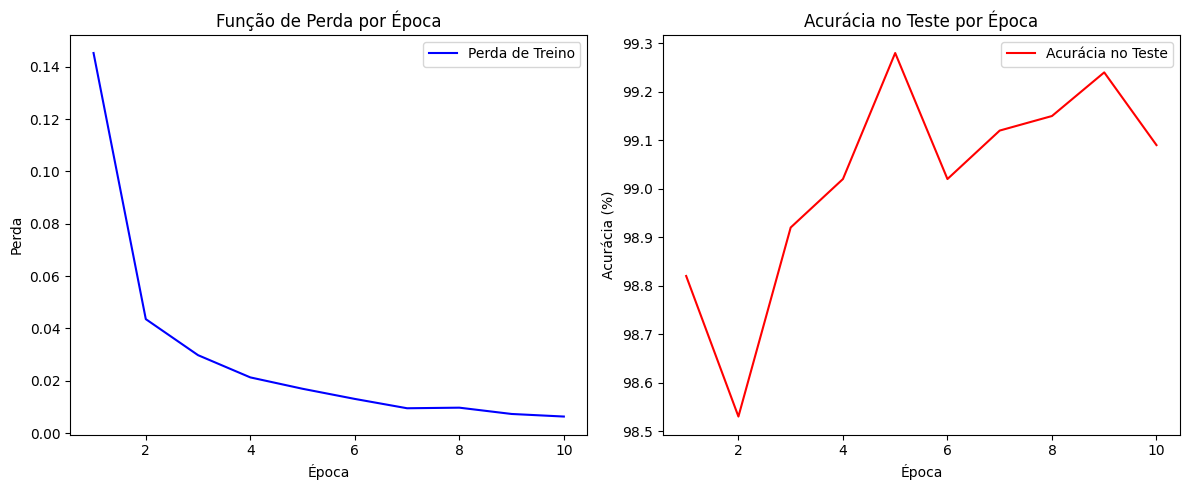

In [ ]:
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

# Verificar se CUDA está disponível
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo de execução: {device}')

# Definir transformações
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Carregar conjunto de dados (substitua pelo seu dataset do Lab 06)
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Criar data loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x)
        return x

# Instanciar a rede e mover para GPU
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
train_loss_history = []
test_accuracy_history = []

for epoch in range(num_epochs):
    # Treinamento
    model.train()
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        # Mover dados para GPU
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass e otimização
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Calcular perda média por época
    epoch_loss = running_loss / len(train_loader)
    train_loss_history.append(epoch_loss)

    # Avaliação no conjunto de teste
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_accuracy = 100 * correct / total
    test_accuracy_history.append(epoch_accuracy)

    print(f'Época [{epoch+1}/{num_epochs}], Perda: {epoch_loss:.4f}, Acurácia: {epoch_accuracy:.2f}%')

print('Treinamento concluído!')

# Gráfico da função de perda
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_loss_history, 'b-', label='Perda de Treino')
plt.title('Função de Perda por Época')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()

# Gráfico da acurácia no teste
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), test_accuracy_history, 'r-', label='Acurácia no Teste')
plt.title('Acurácia no Teste por Época')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.legend()

plt.tight_layout()
plt.show()

### Questão nº 02 (2 pts)

Refaça a questão anterior, mas agora com a base de dados MNIST.

In [ ]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784')
# 70000 imagens 28x28 de dígitos (0-9)
images = mnist.data.to_numpy().reshape((-1,28,28))
# o rótulo do dígito (0 a 9)
targets = mnist.target


Dispositivo utilizado: cuda
MNIST_CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout2d(p=0.25, inplace=False)
  (dropout2): Dropout2d(p=0.5, inplace=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:1538: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


Época 1/15 | Perda: 0.2113 | Acurácia: 98.49%
Época 2/15 | Perda: 0.0898 | Acurácia: 98.58%
Época 3/15 | Perda: 0.0679 | Acurácia: 98.95%
Época 4/15 | Perda: 0.0589 | Acurácia: 98.94%
Época 5/15 | Perda: 0.0501 | Acurácia: 99.02%
Época 6/15 | Perda: 0.0331 | Acurácia: 99.17%
Época 7/15 | Perda: 0.0268 | Acurácia: 99.18%
Época 8/15 | Perda: 0.0239 | Acurácia: 99.17%
Época 9/15 | Perda: 0.0232 | Acurácia: 99.19%
Época 10/15 | Perda: 0.0198 | Acurácia: 99.29%
Época 11/15 | Perda: 0.0191 | Acurácia: 99.31%
Época 12/15 | Perda: 0.0192 | Acurácia: 99.28%
Época 13/15 | Perda: 0.0184 | Acurácia: 99.30%
Época 14/15 | Perda: 0.0183 | Acurácia: 99.30%
Época 15/15 | Perda: 0.0180 | Acurácia: 99.27%


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

...

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

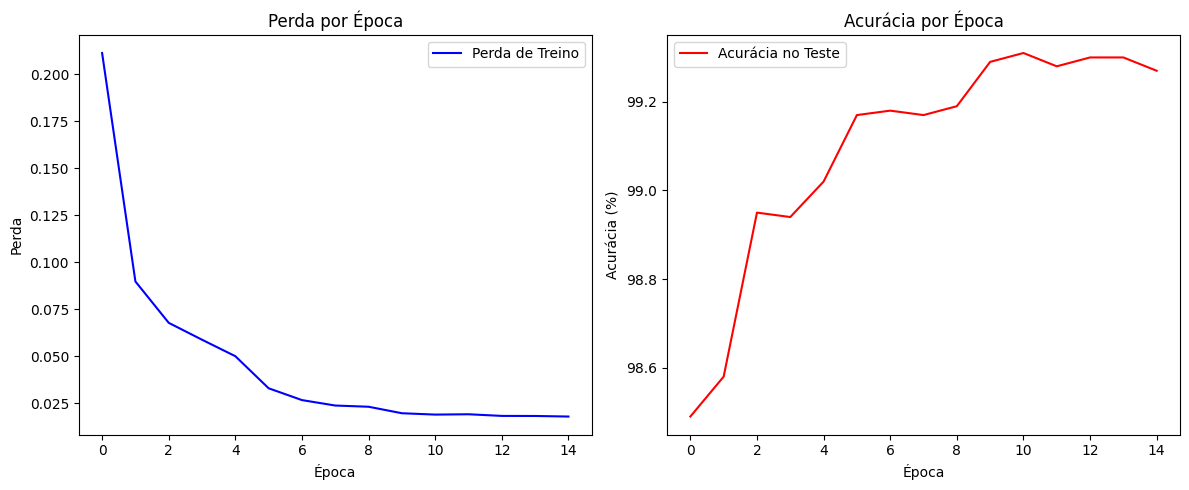

Acurácia final no conjunto de teste: 99.27%


In [ ]:
#Faça aqui!
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Configurar device (CUDA se disponível)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo utilizado: {device}')

# Transformações para normalizar os dados
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # Valores médios e std do MNIST
])

# Carregar conjuntos de treino e teste
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Criar DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)  # Camada convolucional 1
        self.conv2 = nn.Conv2d(32, 64, 3, 1)  # Camada convolucional 2
        self.dropout1 = nn.Dropout2d(0.25)
        self.dropout2 = nn.Dropout2d(0.5)
        self.fc1 = nn.Linear(9216, 128)       # Camada fully connected 1
        self.fc2 = nn.Linear(128, 10)         # Camada de saída

    def forward(self, x):
        x = self.conv1(x)           # Conv1
        x = nn.functional.relu(x)   # ReLU
        x = self.conv2(x)           # Conv2
        x = nn.functional.relu(x)   # ReLU
        x = nn.functional.max_pool2d(x, 2)  # Max pooling
        x = self.dropout1(x)       # Dropout
        x = torch.flatten(x, 1)    # Flatten
        x = self.fc1(x)            # FC1
        x = nn.functional.relu(x)   # ReLU
        x = self.dropout2(x)        # Dropout
        x = self.fc2(x)            # Saída
        return x

# Instanciar e mover para GPU
model = MNIST_CNN().to(device)
print(model)

# Função de perda e otimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Agendador de learning rate
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

num_epochs = 15
train_loss_history = []
test_accuracy_history = []

for epoch in range(num_epochs):
    # Fase de treino
    model.train()
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Calcular perda média
    epoch_loss = running_loss / len(train_loader)
    train_loss_history.append(epoch_loss)

    # Fase de teste
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    accuracy = 100 * correct / total
    test_accuracy_history.append(accuracy)

    # Atualizar learning rate
    scheduler.step()

    print(f'Época {epoch+1}/{num_epochs} | Perda: {epoch_loss:.4f} | Acurácia: {accuracy:.2f}%')

    plt.figure(figsize=(12, 5))

# Gráfico de perda
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Perda de Treino', color='blue')
plt.title('Perda por Época')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()

# Gráfico de acurácia
plt.subplot(1, 2, 2)
plt.plot(test_accuracy_history, label='Acurácia no Teste', color='red')
plt.title('Acurácia por Época')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.legend()

plt.tight_layout()
plt.show()

# Calcular acurácia final
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        outputs = model(data)
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

print(f'Acurácia final no conjunto de teste: {100 * correct / total:.2f}%')

### Questão nº 03 (3 pts)

Redes neurais convolucionais também são "boas" para lidar com dados com informações temporais. A convolução captura informações de vizinhança em imagens, e é capaz de fazer o mesmo em vetores com medições feitas ao longo do tempo. Essa não é uma tarefa de visão computacional, mas mostra uma possibilidade de uso de redes neurais convolucionais!

Um dos conjuntos de dados do United States National Renewable Energy Laboratory representa um índice de irradiância solar em 16 localizações distintas. Cada ponto representa uma medição desse valor, feita a cada 15 minutos.

**A tarefa, neste caso, é prever a irradiação solar em cada um dos pontos a cada 15 minutos, com base nas 2 medições anteriores. Para isso, você deve utilizar uma rede neural convolucional!**

Assim, na entrada você terá a medição atual e a de 15 minutos atrás, e você quer prever a medição de daqui 15 minutos.

O código abaixo pré-processa as séries temporais e as converte em uma matriz com várias amostras de 32 elementos (2 amostras por local), onde cada uma possui targets de tamanho 16 (1 amostra por local).

X possui 22165 linhas por 32 colunas, enquanto Y (alvo) possui a mesma quantidade de linhas e 16 colunas.

Cuidado! Não embaralhe esses dados. Eles estão organizados de forma com que, temporalmente, a segunda amostra ocorreu após a primeira e antes da terceira, e assim sucessivamente. Ao separar entre treino e teste, separe as N últimas amostras como teste sem embaralhar.

Utilize uma rede neural convolucional com camadas unidimensionais [torch.nn.Conv1d](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv1d.html) para tentar prever esses valores.

Lembre-se, é um problema de regressão (previsão de valores, e não de classes), então sua função de perda não pode ser nada relacionada a métricas de classificação. E os dados, agora, não são 2-D!

Dica: Use o erro quadrático médio para calcular o erro entre a predição e o valor real. Use o [torch.nn.functional.mse_loss](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.mse_loss.html), que recebe dois tensores e retorna o erro quadrático médio entre elas.

Desenhe também um gráfico da evolução do erro quadrático médio ao longo das épocas, como feito nas questões 1 e 2.

Escolha algumas amostras e faça gráficos comparando o valor previsto com o valor real;




In [ ]:
# Você pode ignorar essa célula, ela apenas carrega e pré-processa a base de dados.
# Faça a questão na próxima célula!
import pandas as pd
import datetime

def normalize(df):
    mindf = df.min()
    maxdf = df.max()
    return (df-mindf)/(maxdf-mindf)

def getRollingWindow(index):
    pivot = index
    train_start = pivot.strftime('%Y-%m-%d')
    pivot = pivot + datetime.timedelta(days=20)
    train_end = pivot.strftime('%Y-%m-%d')

    pivot = pivot + datetime.timedelta(days=1)
    validation_start = pivot.strftime('%Y-%m-%d')
    pivot = pivot + datetime.timedelta(days=6)
    validation_end = pivot.strftime('%Y-%m-%d')

    pivot = pivot + datetime.timedelta(days=1)
    test_start = pivot.strftime('%Y-%m-%d')
    pivot = pivot + datetime.timedelta(days=6)
    test_end = pivot.strftime('%Y-%m-%d')

    return train_start, train_end, validation_start, validation_end, test_start, test_end

# convert series to supervised learning
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    df = pd.DataFrame(data)
    cols, names = list(), list()
    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    # forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    # put it all together
    agg = pd.concat(cols, axis=1)
    agg.columns = names
    # drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg

df = pd.read_csv('https://query.data.world/s/wo5wryokqyg5uvbfqqij2mucgwly5u',  parse_dates=['datetime'], index_col=0)
interval = ((df.index >= '2010-06') & (df.index < '2011-06'))
df = df.loc[interval]
df = normalize(df)

# Split data
interval = ((df.index >= '2010-06') & (df.index < '2011-06'))
df = df.loc[interval]

limit = df.index[-1].strftime('%Y-%m-%d')

test_end = ""
index = df.index[0]
batches = []
batches_supervised = []
_order = 2
_step = 1
nobs = _order * len(df.columns)
output_index = -len(df.columns)*_step

while test_end < limit:

    #print("Index: ", index.strftime('%Y-%m-%d'))

    train_start, train_end, validation_start, validation_end, test_start, test_end = getRollingWindow(index)
    index = index + datetime.timedelta(days=7)

    train = df[train_start : train_end]
    validation = df[validation_start : validation_end]
    test = df[test_start : test_end]
    train = pd.concat([train,validation],ignore_index=True)

    if len(batches) == 0:
        batches.append(train)
        train_reshaped_df = series_to_supervised(train,n_in=_order,n_out=_step)
        train_X, train_Y = train_reshaped_df.iloc[:, :nobs].values, train_reshaped_df.iloc[:, output_index:].values
        batches_supervised.append((train_X,train_Y))

    batches.append(test)
    test_reshaped_df = series_to_supervised(test,n_in=_order,n_out=_step)
    test_X, test_Y = test_reshaped_df.iloc[:, :nobs].values, test_reshaped_df.iloc[:, output_index:].values
    batches_supervised.append((test_X,test_Y))

x = []
y = []

for i in range(len(batches_supervised)):
  x.append(batches_supervised[i][0])
  y.append(batches_supervised[i][1])

x = np.concatenate(x)
y = np.concatenate(y)
x_train = x[:17732,:]
y_train = y[:17732,:]
x_test = x[17732:,:]
y_test = y[17732:,:]

Dispositivo utilizado: cuda
SolarIrradianceCNN(
  (conv1): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv3): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (fc1): Linear(in_features=8192, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=16, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)
Epoch 1/50 | Train Loss: 0.998856 | Test Loss: 1.003085
Epoch 2/50 | Train Loss: 0.998597 | Test Loss: 1.003084
Epoch 3/50 | Train Loss: 0.998541 | Test Loss: 1.003072
Epoch 4/50 | Train Loss: 0.998505 | Test Loss: 1.002990
Epoch 5/50 | Train Loss: 0.998481 | Test Loss: 1.003008
Epoch 6/50 | Train Loss: 0.998340 | Test Loss: 1.002964
Epoch 7/50 | Train Loss: 0.998235 | Test Loss: 1.003024
Epoch 8/50 | Train Loss: 0.998026 | Test Loss: 1.003433
Epoch 9/50 | Train Loss: 0.997504 | Test Loss: 1.004678
Ep

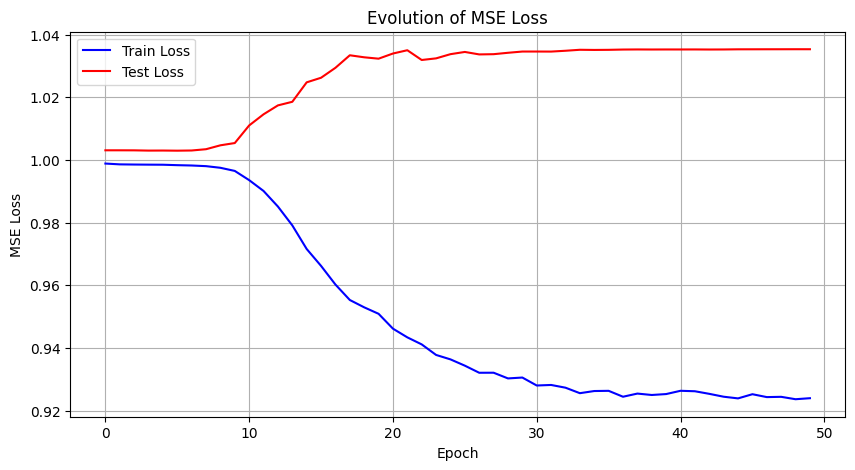

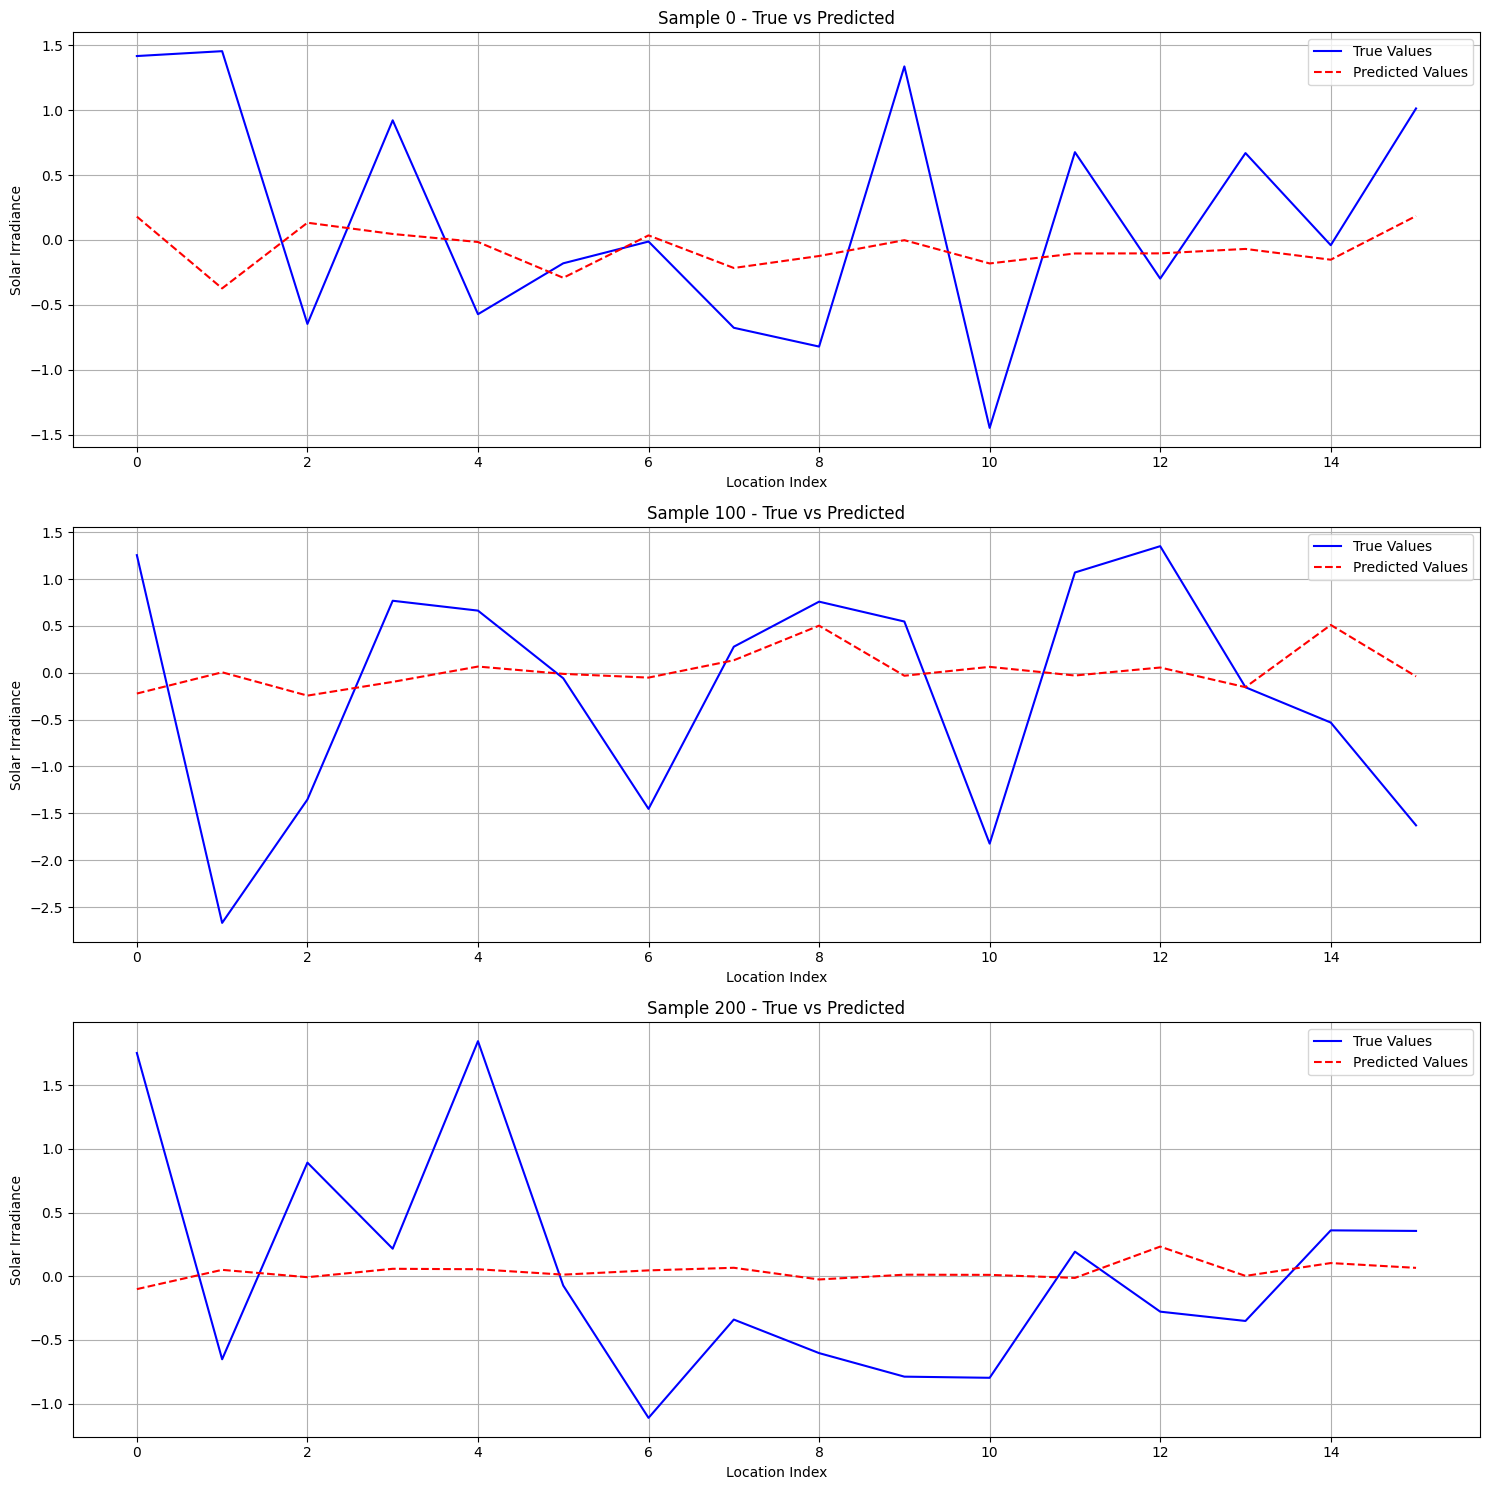

In [ ]:
# Faça aqui
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

# Configurar device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo utilizado: {device}')

# Dados de exemplo (substitua pelos seus dados reais)
# X shape: (22165, 32) - 2 medições (atual e 15min atrás) para 16 locais
# Y shape: (22165, 16) - próxima medição para cada local
X = np.random.randn(22165, 32)  # Substitua por seus dados reais
Y = np.random.randn(22165, 16)   # Substitua por seus dados reais

# Divisão treino/teste (mantendo ordem temporal)
test_size = 0.2
split_idx = int(len(X) * (1 - test_size))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = Y[:split_idx], Y[split_idx:]

# Converter para tensores PyTorch
X_train = torch.FloatTensor(X_train).to(device)
X_test = torch.FloatTensor(X_test).to(device)
y_train = torch.FloatTensor(y_train).to(device)
y_test = torch.FloatTensor(y_test).to(device)

# DataLoaders
batch_size = 64
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
test_dataset = torch.utils.data.TensorDataset(X_test, y_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class SolarIrradianceCNN(nn.Module):
    def __init__(self):
        super(SolarIrradianceCNN, self).__init__()
        # Camada convolucional 1D
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1)

        # Camadas fully connected
        self.fc1 = nn.Linear(256 * 32, 512)  # 32 é o tamanho original da sequência
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 16)  # Saída para 16 locais

        # Dropout para regularização
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # Reshape para (batch_size, channels, sequence_length)
        x = x.unsqueeze(1)  # Adiciona dimensão do canal

        # Camadas convolucionais com ReLU e max pooling
        x = F.relu(self.conv1(x))
        x = self.dropout(x)
        x = F.relu(self.conv2(x))
        x = self.dropout(x)
        x = F.relu(self.conv3(x))
        x = self.dropout(x)

        # Flatten para fully connected
        x = x.view(x.size(0), -1)

        # Camadas fully connected
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x

# Instanciar modelo
model = SolarIrradianceCNN().to(device)
print(model)

# Função de perda e otimizador
criterion = nn.MSELoss()  # Erro quadrático médio para regressão
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

num_epochs = 50
train_loss_history = []
test_loss_history = []

for epoch in range(num_epochs):
    # Treinamento
    model.train()
    train_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)

    # Calcular perda média de treino
    train_loss = train_loss / len(train_loader.dataset)
    train_loss_history.append(train_loss)

    # Avaliação no teste
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item() * inputs.size(0)

    test_loss = test_loss / len(test_loader.dataset)
    test_loss_history.append(test_loss)

    # Ajustar learning rate
    scheduler.step(test_loss)

    print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}')

    # Gráfico da evolução do erro
plt.figure(figsize=(10, 5))
plt.plot(train_loss_history, label='Train Loss', color='blue')
plt.plot(test_loss_history, label='Test Loss', color='red')
plt.title('Evolution of MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

# Gráficos de comparação para algumas amostras
model.eval()
with torch.no_grad():
    # Pegar algumas amostras do conjunto de teste
    sample_indices = [0, 100, 200]  # Exemplos aleatórios
    plt.figure(figsize=(15, 5 * len(sample_indices)))

    for i, idx in enumerate(sample_indices):
        inputs = X_test[idx].unsqueeze(0)
        true_output = y_test[idx].cpu().numpy()
        pred_output = model(inputs).squeeze().cpu().numpy()

        # Plot
        plt.subplot(len(sample_indices), 1, i+1)
        plt.plot(true_output, 'b-', label='True Values')
        plt.plot(pred_output, 'r--', label='Predicted Values')
        plt.title(f'Sample {idx} - True vs Predicted')
        plt.xlabel('Location Index')
        plt.ylabel('Solar Irradiance')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()